# Baseline Iris Classification

This notebook introduces the Iris dataset and compares several classical machine learning models before any tuning is applied. The goal is to establish a fair baseline, inspect the feature distributions, and identify which model performs best on a simple train/test split.

What this notebook shows:

- the structure and class balance of the Iris dataset
- the main feature distributions and pairwise relationships
- a comparison of baseline classifiers using the same split
- a confusion matrix for the strongest baseline model

Use the plots to see how the three Iris species separate in petal and sepal measurements. Use the accuracy and classification report to understand which model is most reliable before moving to the full pipeline notebook.


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [45]:
df = pd.read_csv(r'C:\Users\LOQ\Documents\Papers\Iris\data\iris.csv')

In [46]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [47]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [49]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")
    print("____________________")

sepal_length: [5.1 4.9 4.7 4.6 5.  5.4 4.4 4.8 4.3 5.8 5.7 5.2 5.5 4.5 5.3 7.  6.4 6.9
 6.5 6.3 6.6 5.9 6.  6.1 5.6 6.7 6.2 6.8 7.1 7.6 7.3 7.2 7.7 7.4 7.9]
____________________
sepal_width: [3.5 3.  3.2 3.1 3.6 3.9 3.4 2.9 3.7 4.  4.4 3.8 3.3 4.1 4.2 2.3 2.8 2.4
 2.7 2.  2.2 2.5 2.6]
____________________
petal_length: [1.4 1.3 1.5 1.7 1.6 1.1 1.2 1.  1.9 4.7 4.5 4.9 4.  4.6 3.3 3.9 3.5 4.2
 3.6 4.4 4.1 4.8 4.3 5.  3.8 3.7 5.1 3.  6.  5.9 5.6 5.8 6.6 6.3 6.1 5.3
 5.5 6.7 6.9 5.7 6.4 5.4 5.2]
____________________
petal_width: [0.2 0.4 0.3 0.1 0.5 0.6 1.4 1.5 1.3 1.6 1.  1.1 1.8 1.2 1.7 2.5 1.9 2.1
 2.2 2.  2.4 2.3]
____________________
species: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
____________________


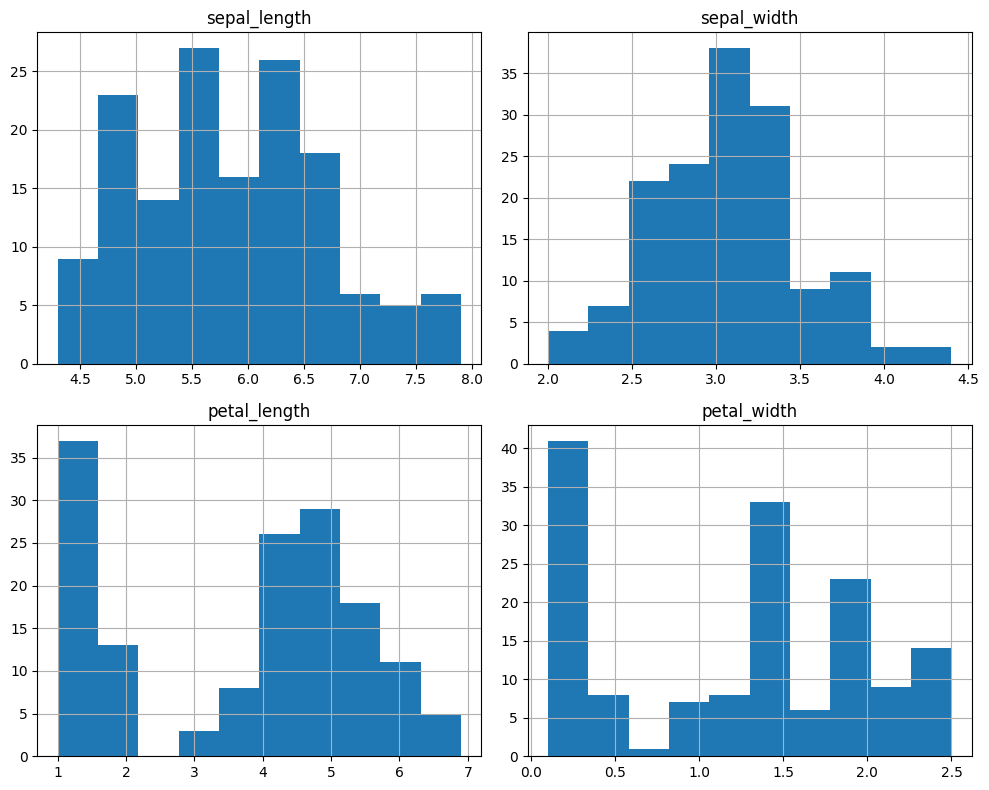

In [50]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

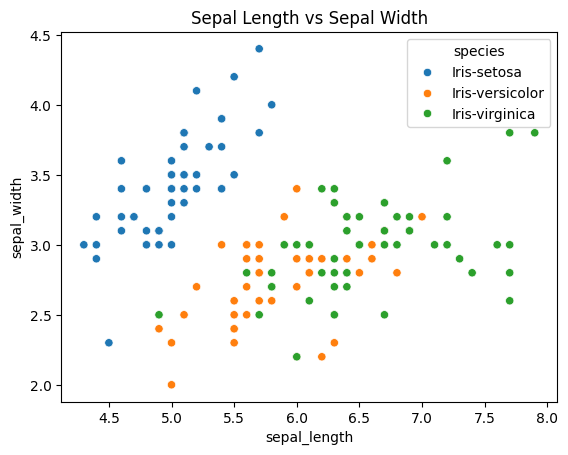

In [51]:
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')
plt.title('Sepal Length vs Sepal Width')
plt.show()

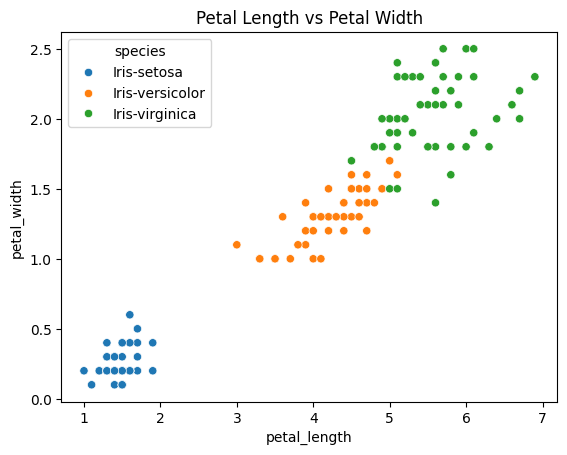

In [52]:
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.title('Petal Length vs Petal Width')
plt.show()

## Baseline Model Comparison

The next section compares several classical classifiers under the same evaluation setup. This makes the results easier to compare because each model sees the same training and test split.

The baseline set includes k-nearest neighbors, decision tree, support vector machine, random forest, and Gaussian Naive Bayes. The best model from this round becomes the reference point for the later pipeline notebook.


In [53]:
target_col = 'species'
X = df.drop(columns=[target_col])
y = df[target_col]

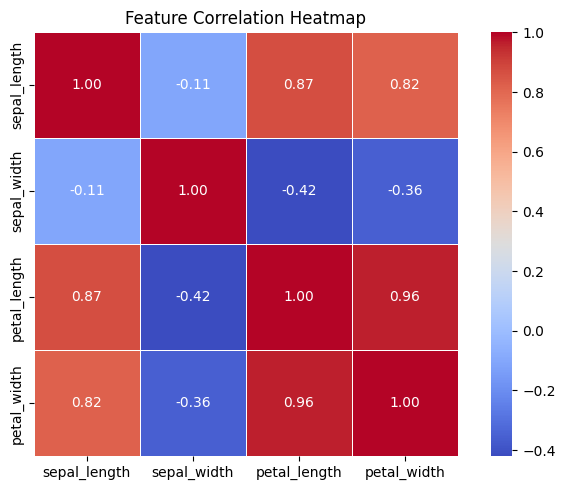

In [54]:
corr = X.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


In [56]:
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [57]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [58]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gaussian NB': GaussianNB()
}

In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

In [60]:
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': test_acc
    })

results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,CV Mean Accuracy,CV Std,Test Accuracy
0,Gaussian NB,0.950000,0.016667,0.966667
1,SVM (RBF),0.966667,0.016667,0.966667
2,KNN,0.958333,0.026352,0.933333
3,Logistic Regression,0.958333,0.026352,0.933333
4,Decision Tree,0.950000,0.016667,0.933333
5,Random Forest,0.950000,0.031180,0.900000


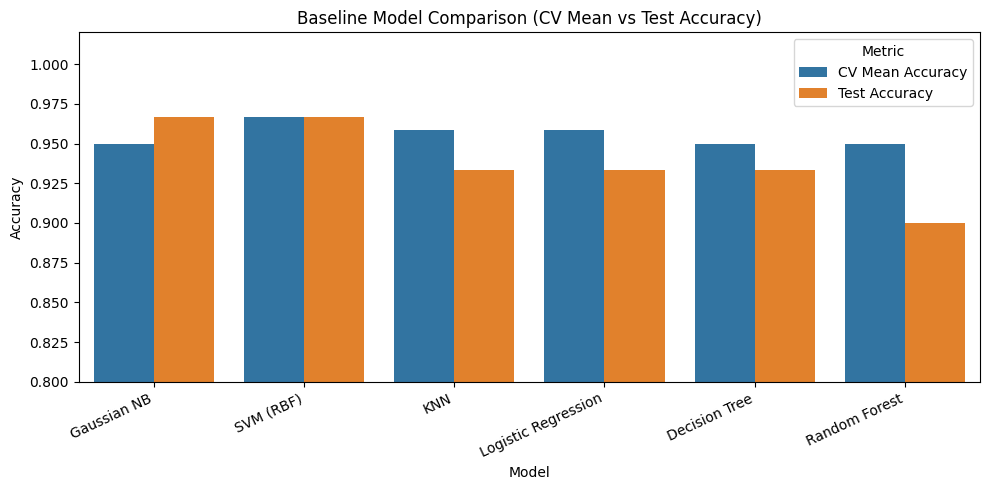

In [66]:
plot_df = results_df[['Model', 'CV Mean Accuracy', 'Test Accuracy']].copy()
plot_df = plot_df.sort_values('Test Accuracy', ascending=False)

plot_long = plot_df.melt(
    id_vars='Model',
    value_vars=['CV Mean Accuracy', 'Test Accuracy'],
    var_name='Metric',
    value_name='Accuracy'
 )

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_long, x='Model', y='Accuracy', hue='Metric')
plt.ylim(0.80, 1.02)
plt.title('Baseline Model Comparison (CV Mean vs Test Accuracy)')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [61]:
best_model_name = results_df.loc[0, 'Model']
print(f"Best model based on test accuracy: {best_model_name}")
print(f"Test Accuracy: {results_df.loc[0, 'Test Accuracy']:.4f}")
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

Best model based on test accuracy: Gaussian NB
Test Accuracy: 0.9667


In [62]:
best_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

Best model: Gaussian NB
Test Accuracy: 0.9667

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



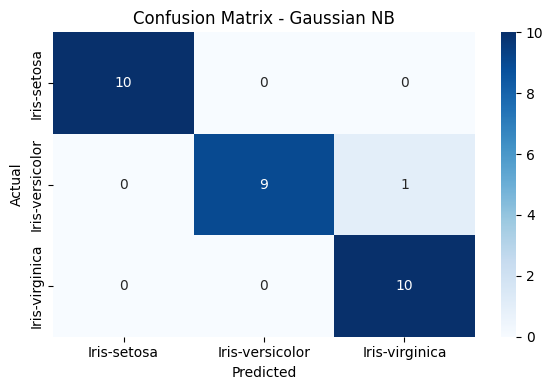

In [63]:
print(f'Best model: {best_model_name}')
print(f'Test Accuracy: {accuracy_score(y_test, best_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()